In [13]:
# cell 1
!pip install -q ultralytics opencv-python-headless requests tqdm

import os
import cv2
import glob
import json
import numpy as np
import requests
from tqdm import tqdm
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [14]:
# cell 2
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [15]:
#cell 3
DATASET_ROOT = "/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103"  # adjust to your actual dataset slug

for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:3]:
            print(f"{indent}  {f}")

FoodSeg103/
  category_id.txt
  train_test_recipe1m_id.txt
  Readme.txt
  Images/
    img_dir/
      test/
      train/
    ann_dir/
      test/
      train/
  ImageSets/
    test.txt
    train.txt


In [16]:
#cell 4
DATASET_ROOT = "/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103"
OUT_LABELS_ROOT = "/kaggle/working/yolo_labels"

def mask_to_yolo_polygons(mask_path, img_w, img_h, min_area=50):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    class_ids = np.unique(mask)
    class_ids = class_ids[class_ids != 0]

    lines = []
    for cls_id in class_ids:
        binary = (mask == cls_id).astype(np.uint8)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) < min_area:
                continue
            cnt = cnt.reshape(-1, 2)
            norm = []
            for x, y in cnt:
                norm.append(x / img_w)
                norm.append(y / img_h)
            line = f"{int(cls_id) - 1} " + " ".join(f"{v:.6f}" for v in norm)
            lines.append(line)
    return lines

for split in ["train", "test"]:
    IMG_DIR = f"{DATASET_ROOT}/Images/img_dir/{split}"
    MASK_DIR = f"{DATASET_ROOT}/Images/ann_dir/{split}"
    OUT_LABELS = f"{OUT_LABELS_ROOT}/{split}"
    os.makedirs(OUT_LABELS, exist_ok=True)

    mask_files = glob.glob(f"{MASK_DIR}/*.png")
    print(f"Processing {split}: {len(mask_files)} masks found")

    for mask_path in tqdm(mask_files):
        fname = os.path.basename(mask_path).replace(".png", "")
        img_path = f"{IMG_DIR}/{fname}.jpg"
        if not os.path.exists(img_path):
            img_path = f"{IMG_DIR}/{fname}.png"
            if not os.path.exists(img_path):
                continue

        img = cv2.imread(img_path)
        if img is None:          # <-- fix: skip unreadable/corrupt images
            continue
        h, w = img.shape[:2]

        lines = mask_to_yolo_polygons(mask_path, w, h)
        with open(f"{OUT_LABELS}/{fname}.txt", "w") as f:
            f.write("\n".join(lines))

print("Done converting masks to YOLO-Seg format for train and test.")

Processing train: 4983 masks found


100%|██████████| 4983/4983 [03:27<00:00, 24.03it/s]


Processing test: 2135 masks found


100%|██████████| 2135/2135 [00:37<00:00, 57.55it/s]

Done converting masks to YOLO-Seg format for train and test.


In [17]:
# cell 5
import shutil

YOLO_ROOT = "/kaggle/working/foodseg_yolo"
for split in ["train", "val"]:
    os.makedirs(f"{YOLO_ROOT}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_ROOT}/labels/{split}", exist_ok=True)

# FoodSeg103 only ships train/test — use "test" as our "val" split
SPLIT_MAP = {"train": "train", "test": "val"}

for src_split, dst_split in SPLIT_MAP.items():
    src_img_dir = f"{DATASET_ROOT}/Images/img_dir/{src_split}"
    src_label_dir = f"{OUT_LABELS_ROOT}/{src_split}"

    for img_path in tqdm(glob.glob(f"{src_img_dir}/*"), desc=f"images:{dst_split}"):
        fname = os.path.basename(img_path)
        shutil.copy(img_path, f"{YOLO_ROOT}/images/{dst_split}/{fname}")

    for label_path in glob.glob(f"{src_label_dir}/*.txt"):
        fname = os.path.basename(label_path)
        shutil.copy(label_path, f"{YOLO_ROOT}/labels/{dst_split}/{fname}")

# Real FoodSeg103 category names instead of placeholders
category_file = f"{DATASET_ROOT}/category_id.txt"
id_to_name = {}
with open(category_file) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split("\t") if "\t" in line else line.split(None, 1)
        cid, name = int(parts[0]), parts[1].strip()
        id_to_name[cid] = name

# category id 0 = background; YOLO class i corresponds to category id i+1
CLASS_NAMES = [id_to_name[i + 1] for i in range(len(id_to_name) - 1)]

yaml_content = f"""
path: {YOLO_ROOT}
train: images/train
val: images/val
nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""
with open(f"{YOLO_ROOT}/data.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)

images:val: 100%|██████████| 2135/2135 [00:03<00:00, 552.08it/s]



path: /kaggle/working/foodseg_yolo
train: images/train
val: images/val
nc: 103
names: ['candy', 'egg tart', 'french fries', 'chocolate', 'biscuit', 'popcorn', 'pudding', 'ice cream', 'cheese butter', 'cake', 'wine', 'milkshake', 'coffee', 'juice', 'milk', 'tea', 'almond', 'red beans', 'cashew', 'dried cranberries', 'soy', 'walnut', 'peanut', 'egg', 'apple', 'date', 'apricot', 'avocado', 'banana', 'strawberry', 'cherry', 'blueberry', 'raspberry', 'mango', 'olives', 'peach', 'lemon', 'pear', 'fig', 'pineapple', 'grape', 'kiwi', 'melon', 'orange', 'watermelon', 'steak', 'pork', 'chicken duck', 'sausage', 'fried meat', 'lamb', 'sauce', 'crab', 'fish', 'shellfish', 'shrimp', 'soup', 'bread', 'corn', 'hamburg', 'pizza', 'hanamaki baozi', 'wonton dumplings', 'pasta', 'noodles', 'rice', 'pie', 'tofu', 'eggplant', 'potato', 'garlic', 'cauliflower', 'tomato', 'kelp', 'seaweed', 'spring onion', 'rape', 'ginger', 'okra', 'lettuce', 'pumpkin', 'cucumber', 'white radish', 'carrot', 'asparagus', 'ba

In [18]:
# cell 6
model = YOLO("yolov8n-seg.pt")  # or yolov8s-seg.pt for better accuracy

results = model.train(
    data=f"{YOLO_ROOT}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/kaggle/working/runs",
    name="platecalc_seg"
)

best_model_path = "/kaggle/working/runs/platecalc_seg/weights/best.pt"

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/foodseg_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=platecalc_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [24]:
#cell 7
def preprocess_image(image_path, target_size=640):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def load_image_for_inference(image_path):
    return preprocess_image(image_path)

In [43]:
#cell 8
trained_model = YOLO(best_model_path)

def run_inference(image_path, conf_threshold=0.05):
    results = trained_model.predict(image_path, conf=conf_threshold)
    return results[0]

def extract_detections(result):
    detections = []
    if result.masks is None:
        return detections

    for i, mask in enumerate(result.masks.data):
        cls_id = int(result.boxes.cls[i].item())
        cls_name = result.names[cls_id]
        mask_np = mask.cpu().numpy().astype(np.uint8)
        area_px = int(np.sum(mask_np))
        detections.append({
            "class_id": cls_id,
            "class_name": cls_name,
            "mask": mask_np,
            "area_px": area_px
        })
    return detections

In [47]:
# cell 9
# Foods counted as discrete instances vs. foods measured by area
COUNTABLE_FOODS = {"banana", "apple", "egg", "orange"}  # extend based on your class names

AVERAGE_WEIGHTS_G = {
    "banana": 118,
    "apple": 182,
    "egg": 50,
    "orange": 131,
}

def count_instances(mask):
    num_labels, labels = cv2.connectedComponents(mask)
    return num_labels - 1  # subtract background

def estimate_quantity(detection, image_area_px, plate_reference_area_g_per_px=None):
    cls_name = detection["class_name"]
    mask = detection["mask"]

    if cls_name in COUNTABLE_FOODS:
        instance_count = count_instances(mask)
        avg_weight = AVERAGE_WEIGHTS_G.get(cls_name, 100)  # default fallback
        return instance_count * avg_weight
    else:
        # area-based: proportion of image area, scaled to an assumed plate weight
        area_ratio = detection["area_px"] / image_area_px
        # Heuristic: assume full plate coverage of a food ~= 300g as a baseline
        estimated_weight = area_ratio * 300
        return estimated_weight

In [51]:
# cell 10

def get_calories_per_100g(food_name):
    url = "https://api.nal.usda.gov/fdc/v1/foods/search"
    params = {"api_key": USDA_API_KEY, "query": food_name, "pageSize": 1}
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
    except (requests.RequestException, ValueError):
        return None

    if not data.get("foods"):
        return None

    food = data["foods"][0]
    for nutrient in food.get("foodNutrients", []):
        if nutrient.get("nutrientName") == "Energy":
            return nutrient.get("value")
    return None

nutrition_cache = {}

def get_cached_calories(food_name):
    if food_name not in nutrition_cache:
        nutrition_cache[food_name] = get_calories_per_100g(food_name)
    return nutrition_cache[food_name]

In [52]:
# cell 11
def compute_meal_calories(image_path):
    img = load_image_for_inference(image_path)
    image_area_px = img.shape[0] * img.shape[1]

    result = run_inference(image_path)
    detections = extract_detections(result)

    breakdown = []
    total_calories = 0

    for det in detections:
        weight_g = estimate_quantity(det, image_area_px)
        cal_per_100g = get_cached_calories(det["class_name"])

        if cal_per_100g is None:
            continue

        calories = (weight_g / 100) * cal_per_100g
        total_calories += calories

        breakdown.append({
            "food": det["class_name"],
            "estimated_weight_g": round(weight_g, 1),
            "calories_per_100g": cal_per_100g,
            "calories": round(calories, 1)
        })

    return {"breakdown": breakdown, "total_calories": round(total_calories, 1)}


image 1/1 /kaggle/input/datasets/ggrill/foodseg103/FoodSeg103/Images/img_dir/test/00007111.jpg: 480x640 1 french fries, 2 cheese butters, 1 almond, 2 lemons, 1 steak, 1 pork, 1 shrimp, 1 potato, 1 carrot, 1 onion, 1 pepper, 8.9ms
Speed: 2.3ms preprocess, 8.9ms inference, 2.7ms postprocess per image at shape (1, 3, 480, 640)
{
  "breakdown": [
    {
      "food": "cheese butter",
      "estimated_weight_g": 7.4,
      "calories_per_100g": 2070.0,
      "calories": 153.9
    },
    {
      "food": "carrot",
      "estimated_weight_g": 1.2,
      "calories_per_100g": 44,
      "calories": 0.5
    },
    {
      "food": "shrimp",
      "estimated_weight_g": 141.0,
      "calories_per_100g": 47.0,
      "calories": 66.3
    },
    {
      "food": "potato",
      "estimated_weight_g": 27.9,
      "calories_per_100g": 171,
      "calories": 47.7
    },
    {
      "food": "steak",
      "estimated_weight_g": 85.3,
      "calories_per_100g": 556,
      "calories": 474.1
    },
    {
      "fo

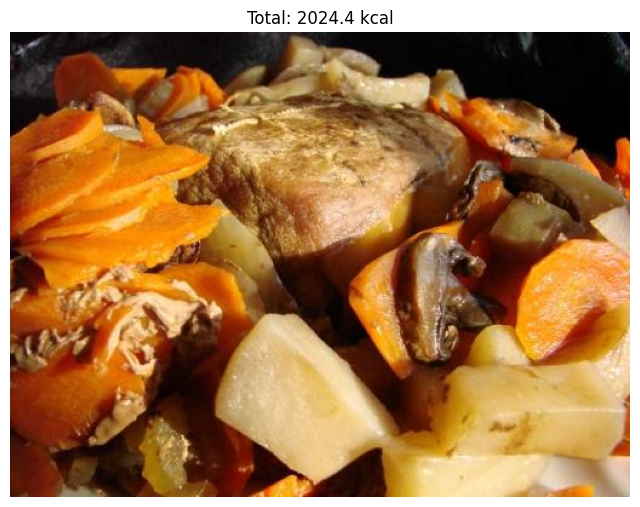

In [53]:
#cell 12
test_image = "/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103/Images/img_dir/test/00007111.jpg"

result = compute_meal_calories(test_image)
print(json.dumps(result, indent=2))

# Visualize
img = cv2.imread(test_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"Total: {result['total_calories']} kcal")
plt.axis("off")
plt.show()

In [42]:
print(best_model_path)
import os
print(os.path.exists(best_model_path))

/kaggle/working/runs/platecalc_seg/weights/best.pt
True


In [35]:
import glob
sample_images = glob.glob("/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103/Images/img_dir/test/*")
print(sample_images[:5])

['/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103/Images/img_dir/test/00007111.jpg', '/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103/Images/img_dir/test/00005029.jpg', '/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103/Images/img_dir/test/00006166.jpg', '/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103/Images/img_dir/test/00004975.jpg', '/kaggle/input/datasets/ggrill/foodseg103/FoodSeg103/Images/img_dir/test/00005750.jpg']


In [ ]:
# MnC 2nd year course overview
# less people -> tight grading
# notes are really important -> go to class
# Use AI well enough 
# Math dept simple eval components(announced or surprised)
# CS courses always a lab test
# Averages are high -> Grading at av is good -> tho tight for A/A-
# Math courses cover almost every single topic in every single eval
# LAA easy course -> high av -> class -> notes -> tutes -> books r very good but some content is skipped
# LAA -> 5 A's at 170+ out of 200
# MCQs r tricky
# OOPs -> Java -> Avs r normal only -> Labs very important -> Slides imp -> Lab sheets -> TB no use 
# Eclipse ID -> learn how to use judicially
# DM -> go to class -> make good notes -> class notes matter -> TB theory not that good
# DM -> sometimes he deletes the solution part 
# ERA -> difficult all abt proofs -> 40/50 theorems -> theorem proof is deleted sometimes -> if deleted read book -> book is really good for books
# Jitendra Kumar notes -> time limit -> Paper do whole first 
# Numerical Analysis -> Accuracy imp -> Ans correct upto 4 decimal places ttdtgrftrdfcfxdftdrdtfdtdfgfgffgfydydrdrftgyvgcfsedddededededdxevgygtfcf